# **Install Dependencies**

In [89]:
!pip install -q langgraph langchain-core langchain-openai python-dotenv ipython


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Program Files\Python311\python.exe -m pip install --upgrade pip


# **Import Libraries**

In [90]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq
from IPython.display import display, Image
from langchain_core.runnables.graph import MermaidDrawMethod
from dotenv import load_dotenv
import os


# **Load environment variables and set API key**

In [91]:
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv('GROQ_API_KEY')
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0
)

# **Define State Structure**

In [92]:
#define the state
class State(TypedDict):
    query: str
    category: str
    sentiment: str
    response: str

# **Define Node Functions**

In [93]:
def categorize(state: State) -> State:
    prompt = ChatPromptTemplate.from_template(
        """
You are an expert customer support routing system.

Your task is to classify the user query into exactly ONE category:

- Technical: issues related to bugs, errors, performance, login issues, crashes, or product functionality
- Billing: payment issues, refunds, subscriptions, invoices, charges, receipts
- General: FAQs, business information, greetings, account questions, non-technical or non-payment queries

Rules:
- Respond with ONLY one word: Technical, Billing, or General
- Do not explain your answer

Customer Query:
{query}
"""
    )

    chain = prompt | llm
    category = chain.invoke({"query": state["query"]}).content.strip()

    return {**state, "category": category}

In [94]:
def analyze_sentiment(state: State) -> State:
    prompt = ChatPromptTemplate.from_template(
        """
You are a sentiment analysis engine for customer support.

Analyze the sentiment of the following customer message.

Return ONLY one label:
- Positive (happy, satisfied, thankful)
- Neutral (informational, unclear emotion, simple question)
- Negative (angry, frustrated, complaint, urgent issue)

Rules:
- Output must be a single word only: Positive, Neutral, or Negative
- No explanations

Customer Query:
{query}
"""
    )

    chain = prompt | llm
    sentiment = chain.invoke({"query": state["query"]}).content.strip()

    return {**state, "sentiment": sentiment}

In [95]:
def handle_technical(state: State) -> State:
    prompt = ChatPromptTemplate.from_template(
        """
You are a senior technical support engineer.

Your job:
- Diagnose the issue clearly
- Provide step-by-step troubleshooting
- Be concise but complete
- If needed, ask a follow-up question
- Avoid vague responses

Customer Issue:
{query}

Response format:
- Short diagnosis
- Steps to fix
- Optional question if needed
"""
    )

    chain = prompt | llm
    response = chain.invoke({"query": state["query"]}).content

    return {**state, "response": response}

In [96]:
def handle_billing(state: State) -> State:
    prompt = ChatPromptTemplate.from_template(
        """
You are a billing support specialist.

Your responsibilities:
- Clearly explain billing-related issues
- Help with refunds, invoices, subscriptions, or charges
- Provide actionable next steps
- Maintain a professional and reassuring tone

Customer Issue:
{query}

Response should include:
- Clear explanation
- What the user should do next
- If needed, mention escalation to billing team
"""
    )

    chain = prompt | llm
    response = chain.invoke({"query": state["query"]}).content

    return {**state, "response": response}

In [97]:
def handle_general(state: State) -> State:
    prompt = ChatPromptTemplate.from_template(
        """
You are a helpful customer support assistant.

Your job:
- Answer general questions clearly and directly
- Keep responses short but useful
- If unsure, guide user to relevant support options

Customer Query:
{query}
"""
    )

    chain = prompt | llm
    response = chain.invoke({"query": state["query"]}).content

    return {**state, "response": response}

In [98]:
def escalate(state: State) -> State:
    return {
        **state,
        "response": (
            "This issue has been escalated to a senior support agent due to high urgency or negative sentiment. "
            "A human agent will review your case shortly and respond with priority."
        )
    }


def route_query(state: State) -> str:
    """Route the query based on its sentiment and category."""
    if state["sentiment"] == "Negative":
        return "escalate"
    elif state["category"] == "Technical":
        return "handle_technical"
    elif state["category"] == "Billing":
        return "handle_billing"
    else:
        return "handle_general"

# **Create and Configure the Graph**

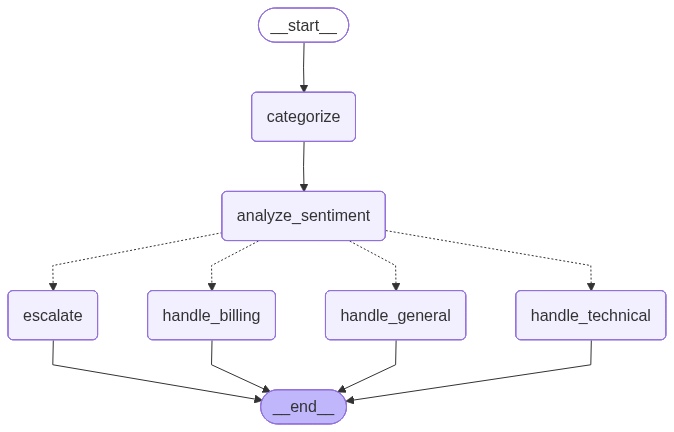

In [99]:
workflow = StateGraph(State)

#add nodes
workflow.add_node("categorize", categorize)
workflow.add_node("analyze_sentiment", analyze_sentiment)
workflow.add_node("handle_technical", handle_technical)
workflow.add_node("handle_billing", handle_billing)
workflow.add_node("handle_general", handle_general)
workflow.add_node("escalate", escalate)

#add edges
workflow.add_edge(START, "categorize")
workflow.add_edge("categorize", "analyze_sentiment")
workflow.add_conditional_edges(
    "analyze_sentiment",
    route_query,
    {
        "handle_technical": "handle_technical",
        "handle_billing": "handle_billing",
        "handle_general": "handle_general",
        "escalate": "escalate"
    }
)
workflow.add_edge("handle_technical", END)
workflow.add_edge("handle_billing", END)
workflow.add_edge("handle_general", END)
workflow.add_edge("escalate", END)



app = workflow.compile()

app

# **Run Customer Support Function**

In [100]:
def run_customer_support(query: str) -> Dict[str, str]:
    """Process a customer query through the LangGraph workflow.
    
    Args:
        query (str): The customer's query
        
    Returns:
        Dict[str, str]: A dictionary containing the query's category, sentiment, and response
    """
    results = app.invoke({"query": query})
    return {
        "category": results["category"],
        "sentiment": results["sentiment"],
        "response": results["response"]
    }

# **Test the Customer Support Agent**

In [101]:
# escalate

query = "I’ve contacted support three times already, but my issue is still not resolved."
result = run_customer_support(query)
print(f"Query: {query}")
print(f"Category: {result['category']}")
print(f"Sentiment: {result['sentiment']}")
print(f"Response: {result['response']}")
print("\n")



Query: I’ve contacted support three times already, but my issue is still not resolved.
Category: Technical
Sentiment: Negative
Response: This issue has been escalated to a senior support agent due to high urgency or negative sentiment. A human agent will review your case shortly and respond with priority.




In [102]:
# handle_technical

query = "My application crashes every time I try to upload a file."
result = run_customer_support(query)
print(f"Query: {query}")
print(f"Category: {result['category']}")
print(f"Sentiment: {result['sentiment']}")
print(f"Response: {result['response']}")
print("\n")

Query: My application crashes every time I try to upload a file.
Category: Technical
Sentiment: Negative
Response: This issue has been escalated to a senior support agent due to high urgency or negative sentiment. A human agent will review your case shortly and respond with priority.




In [103]:
# handle_billing

query = "I was charged twice for my monthly subscription."
result = run_customer_support(query)
print(f"Query: {query}")
print(f"Category: {result['category']}")
print(f"Sentiment: {result['sentiment']}")
print(f"Response: {result['response']}")
print("\n")

Query: I was charged twice for my monthly subscription.
Category: Billing
Sentiment: Negative
Response: This issue has been escalated to a senior support agent due to high urgency or negative sentiment. A human agent will review your case shortly and respond with priority.




In [104]:
# handle_general

query = "Do you offer customer support on weekends?"
result = run_customer_support(query)
print(f"Query: {query}")
print(f"Category: {result['category']}")
print(f"Sentiment: {result['sentiment']}")
print(f"Response: {result['response']}")

Query: Do you offer customer support on weekends?
Category: General
Sentiment: Neutral
Response: Our customer support is available Monday to Friday, 9 AM to 5 PM (your local time). If you have an urgent issue outside of these hours, please visit our website for a list of emergency contact numbers or submit a support request, and we'll get back to you as soon as possible.
